# Week 1 Seminar

A/A experiment analysis

### Перед анализом провели эксперимент
##### cd botify
##### docker-compose up -d --build --force-recreate --scale recommender=2

#### в отдельном терминале:
##### cd sim
##### source venv-sim/bin/activate #активируем предварительно созданное виртуальное окружение
##### python -m sim.run --episodes 1000 --config config/env.yml single --recommender remote --seed 31337

### Cкопируем логи из контейнеров к себе локально
#### из терминала:
##### cd botify
##### docker cp botify-recommender-1:/app/log/ /tmp/runAA/botify-log-1 
##### docker cp botify-recommender-2:/app/log/ /tmp/runAA/botify-log-2

In [35]:
import glob
from collections import namedtuple

import pandas as pd
import numpy as np
import scipy.stats as ss

import matplotlib.pyplot as plt

pd.set_option("display.precision", 3)

%matplotlib inline

In [22]:
!pip install scipy matplotlib

Looking in indexes: https://nexus.odkl.ru/repository/pypi-dev/simple, https://nexus.odkl.ru/repository/pypi-dev/simple

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
experiment = "AA"

In [37]:
data = pd.concat([
    pd.read_json(data_path, lines=True)
    for data_path
    in ["/tmp/runAA/botify-log-1/data.json", "/tmp/runAA/botify-log-2/data.json"]
])

data["treatment"] = data["experiments"].map(lambda experiments: experiments[experiment])

In [25]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-10 15:44:38.362,3255,11385,0.17,1.266e-03,1786.0,{'AA': 'C'},C
1,next,2026-03-10 15:44:38.366,3255,1583,0.08,1.786e-04,2656.0,{'AA': 'C'},C
2,last,2026-03-10 15:44:38.369,3255,844,0.18,5.388e-05,NaN,{'AA': 'C'},C
3,next,2026-03-10 15:44:38.375,7229,2930,0.76,2.325e-04,6947.0,{'AA': 'T1'},T1
4,next,2026-03-10 15:44:38.378,7229,6046,0.52,1.593e-04,2100.0,{'AA': 'T1'},T1
...,...,...,...,...,...,...,...,...,...
4463,next,2026-03-10 15:44:51.962,1661,7583,0.56,1.330e-04,11939.0,{'AA': 'T1'},T1
4464,next,2026-03-10 15:44:51.964,1661,6496,0.50,1.280e-04,14822.0,{'AA': 'T1'},T1
4465,next,2026-03-10 15:44:51.966,1661,9654,0.89,1.392e-04,8307.0,{'AA': 'T1'},T1
4466,next,2026-03-10 15:44:51.967,1661,7272,0.32,1.769e-04,6413.0,{'AA': 'T1'},T1


In [8]:
data

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-10 15:44:38.362,3255,11385,0.17,1.266e-03,1786.0,{'AA': 'C'},C
1,next,2026-03-10 15:44:38.366,3255,1583,0.08,1.786e-04,2656.0,{'AA': 'C'},C
2,last,2026-03-10 15:44:38.369,3255,844,0.18,5.388e-05,NaN,{'AA': 'C'},C
3,next,2026-03-10 15:44:38.375,7229,2930,0.76,2.325e-04,6947.0,{'AA': 'T1'},T1
4,next,2026-03-10 15:44:38.378,7229,6046,0.52,1.593e-04,2100.0,{'AA': 'T1'},T1
...,...,...,...,...,...,...,...,...,...
4463,next,2026-03-10 15:44:51.962,1661,7583,0.56,1.330e-04,11939.0,{'AA': 'T1'},T1
4464,next,2026-03-10 15:44:51.964,1661,6496,0.50,1.280e-04,14822.0,{'AA': 'T1'},T1
4465,next,2026-03-10 15:44:51.966,1661,9654,0.89,1.392e-04,8307.0,{'AA': 'T1'},T1
4466,next,2026-03-10 15:44:51.967,1661,7272,0.32,1.769e-04,6413.0,{'AA': 'T1'},T1


In [26]:
data[
    (data["treatment"] == "C") & 
    (data["user"] == 3255)
].sort_values("timestamp")

,message,timestamp,user,track,time,latency,recommendation,experiments,treatment
0,next,2026-03-10 15:44:38.349,3255,5091,1.00,6.079e-03,11385.0,{'AA': 'C'},C
0,next,2026-03-10 15:44:38.362,3255,11385,0.17,1.266e-03,1786.0,{'AA': 'C'},C
1,next,2026-03-10 15:44:38.365,3255,1786,0.04,2.680e-04,1583.0,{'AA': 'C'},C
1,next,2026-03-10 15:44:38.366,3255,1583,0.08,1.786e-04,2656.0,{'AA': 'C'},C
2,next,2026-03-10 15:44:38.368,3255,2656,0.06,1.500e-04,844.0,{'AA': 'C'},C
2,last,2026-03-10 15:44:38.369,3255,844,0.18,5.388e-05,NaN,{'AA': 'C'},C


In [27]:
data.groupby("treatment").count()

,message,timestamp,user,track,time,latency,recommendation,experiments
treatment,,,,,,,,
C,4420,4420,4420,4420,4420,4420,3929,4420
T1,4515,4515,4515,4515,4515,4515,4006,4515


## Visualize sessions

In [28]:
Session = namedtuple("Session", ["timestamp", "tracks", "time", "latency"])

def sessionize(user_data):
    sessions = []
    session = None
    for _, row in user_data.sort_values("timestamp").iterrows():
        if session is None:
            session = Session(row["timestamp"], 0, 0, 0)
        
        session = session._replace(
            tracks = session.tracks + 1, 
            time = session.time + row["time"],
            latency = session.latency + row["latency"] * 1000,
        )
        
        if row["message"] == "last":
            sessions.append(session._asdict())
            session = None
    return sessions

In [29]:
sessions = (
    data
    .groupby(["user", "treatment"])
    .apply(sessionize)
    .explode()
    .apply(pd.Series)
)

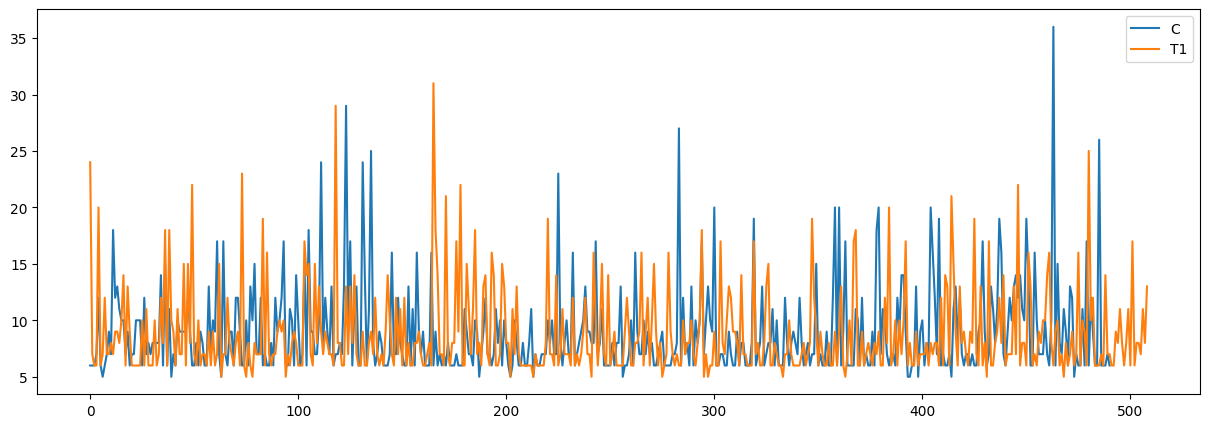

In [30]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["tracks"], label=treatment)
ax.legend()
pass

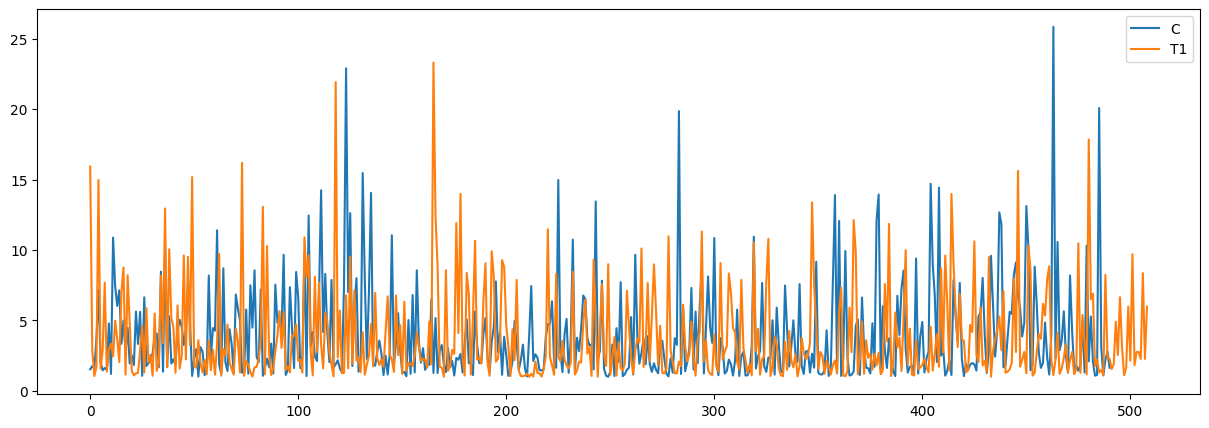

In [31]:
figure, ax = plt.subplots(figsize=(15, 5))
for treatment, treatment_sessions in sessions.groupby("treatment"):
    reindexed_treatment_sessions = treatment_sessions.sort_values("timestamp").reset_index()
    ax.plot(reindexed_treatment_sessions.index, reindexed_treatment_sessions["time"], label=treatment)
ax.legend()
pass

## Analyze the experiment

In [32]:
user_level_data = (
  sessions
    .reset_index()
    .groupby(["user", "treatment"])
    .agg(
        {
            "timestamp": "count",
            "tracks": "sum",
            "time": "sum",
            "latency": "sum"
        }
    )
)

user_level_data["sessions"] = user_level_data["timestamp"]
user_level_data["mean_request_latency"] = user_level_data["latency"] / user_level_data["tracks"]
user_level_data["mean_tracks_per_session"] = user_level_data["tracks"] / user_level_data["sessions"]
user_level_data["mean_time_per_session"] = user_level_data["time"] / user_level_data["sessions"]

metrics = [
    "time", 
    "sessions", 
    "mean_request_latency", 
    "mean_tracks_per_session", 
    "mean_time_per_session"
]

user_level_metrics = user_level_data[metrics].copy().reset_index()

In [33]:
treatment_level_metrics = (
    user_level_metrics
    .groupby("treatment")[metrics]
    .agg(["count", "mean", "var"])
)

In [17]:
def dof(n_0, n_1, s2_0, s2_1):
    numerator = (s2_0 / n_0 + s2_1 / n_1) * (s2_0 / n_0 + s2_1 / n_1)
    denominator = s2_0 * s2_0 / n_0 / n_0 / (n_0 - 1) + s2_1 * s2_1 / n_1 / n_1 / (n_1 - 1)
    return numerator / denominator


def ci(n_0, n_1, s2_0, s2_1, alpha=0.05):
    return ss.t.ppf(1 - alpha/2, dof(n_0, n_1, s2_0, s2_1)) * np.sqrt(s2_0 / n_0 + s2_1 / n_1)


effects = []

control = [data for treatment, data in treatment_level_metrics.iterrows() if treatment == "C"][0]

for treatment, row in treatment_level_metrics.iterrows():
    if treatment == "C":
        continue
    
    for metric in metrics:
        control_mean = control[metric]["mean"]
        treatment_mean = row[metric]["mean"]
        
        effect = treatment_mean - control_mean
        conf_int = ci(
            control[metric]["count"],
            row[metric]["count"],
            control[metric]["var"],
            row[metric]["var"],
        )
        effects.append({
            "treatment": treatment,
            "metric": metric,
            "control_mean": control_mean,
            "treatment_mean": treatment_mean,
            "effect": effect / control_mean * 100,
            "lower": (effect - conf_int) / control_mean * 100,
            "upper": (effect + conf_int) / control_mean * 100,
            "significant": (effect + conf_int) * (effect - conf_int) > 0
        })

In [34]:
def color(value):
    return 'color:red;' if value < 0 else 'color:green;'

def background(value):
    return 'color:white;background-color:green' if value else 'color:white;background-color:red'
        

(
    pd.DataFrame(effects)[[
        "treatment", 
        "metric",
        "effect", 
        "upper", 
        "lower", 
        "control_mean", 
        "treatment_mean",
        "significant"
    ]]
    .sort_values(["metric", "treatment"], ascending=False)
    .style
    .map(color, subset=["effect", "upper", "lower"])
    .map(background, subset=["significant"])
)

,treatment,metric,effect,upper,lower,control_mean,treatment_mean,significant
0,T1,time,-1.623822,10.324672,-13.572317,4.070420,4.004324,False
1,T1,sessions,1.116824,3.565502,-1.331854,1.031513,1.043033,False
3,T1,mean_tracks_per_session,-1.437423,4.015837,-6.890682,8.859244,8.731899,False
4,T1,mean_time_per_session,-2.394628,8.305686,-13.094943,3.903929,3.810444,False
2,T1,mean_request_latency,-1.801426,2.047350,-5.650202,0.149655,0.146959,False


In [19]:
import json


track2artist = {}
with open("/Users/margarita.markova/recsys-course-spring-2026/botify/data/tracks.json") as f:
    for line in f:
        rec = json.loads(line)
        track2artist[rec["track"]] = rec["artist"]


exp_name = "AA"
df = data[data["message"] == "next"].copy()
df["treatment"] = df["experiments"].map(lambda e: e.get(exp_name))


df_sticky = df[df["treatment"] != "C"].copy()


df_sticky["prev_artist"] = df_sticky["track"].map(track2artist)
df_sticky["rec_artist"] = df_sticky["recommendation"].map(track2artist)


share_same = (df_sticky["prev_artist"] == df_sticky["rec_artist"]).mean()
share_same

np.float64(0.0007488766849725411)

In [20]:
# Посчитаем среднее количество повторов трека на пользователя
def count_repeats_for_user(df_user):
    seen = set()
    repeats = 0
    for t in df_user["track"]:
        if t in seen:
            repeats += 1
        else:
            seen.add(t)
    return repeats


data_next = (
    data[data["message"] == "next"]
    .sort_values(["user", "timestamp"])
)

repeats_per_user = data_next.groupby("user").apply(count_repeats_for_user)

mean_repeats = repeats_per_user.mean()
mean_repeats

np.float64(0.0031120331950207467)

In [38]:
import json

#Посчитаем долю prev_artist = rec_artist
track2artist = {}
with open("/Users/margarita.markova/recsys-course-spring-2026/botify/data/tracks.json") as f:
    for line in f:
        rec = json.loads(line)
        track2artist[rec["track"]] = rec["artist"]


exp_name = "AA"
df = data[data["message"] == "next"].copy()
df["treatment"] = df["experiments"].map(lambda e: e.get(exp_name))

df_sticky = df[df["treatment"] != "C"].copy()


df_sticky["prev_artist"] = df_sticky["track"].map(track2artist)
df_sticky["rec_artist"] = df_sticky["recommendation"].map(track2artist)


share_same = (df_sticky["prev_artist"] == df_sticky["rec_artist"]).mean()
share_same

np.float64(0.0015122873345935729)